<a href="https://colab.research.google.com/github/mohits2508sse-lab/ML-LAB-EXPERIMENT/blob/main/EXP_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Data
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

After Positive Example 1
['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']

After Positive Example 2
['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']

After Positive Example 3
['Sunny', 'Warm', '?', 'Strong', '?', '?']

Final Most Specific Hypothesis
['Sunny', 'Warm', '?', 'Strong', '?', '?']


/tmp/ipykernel_11268/1755533071.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if hypothesis[i] != row[i]:


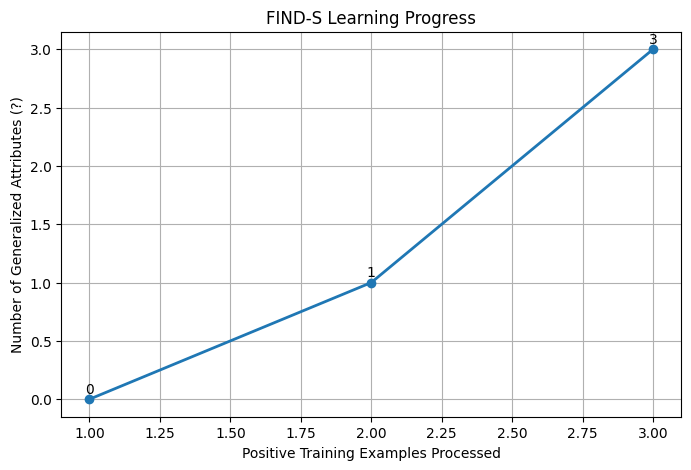

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']
]

columns = ['Sky', 'AirTemp', 'Humidity', 'Wind', 'Water', 'Forecast', 'EnjoySport']

df = pd.DataFrame(data, columns=columns)

print("Training Data")
print(df)

attributes = df.columns[:-1]
hypothesis = ['Ø'] * len(attributes)

history = []
step = 0

for _, row in df.iterrows():
    if row['EnjoySport'] == 'Yes':
        if hypothesis[0] == 'Ø':
            hypothesis = row[:-1].tolist()
        else:
            for i in range(len(hypothesis)):
                if hypothesis[i] != row[i]:
                    hypothesis[i] = '?'

        step += 1
        history.append((step, hypothesis.copy()))

        print("\nAfter Positive Example", step)
        print(hypothesis)

print("\nFinal Most Specific Hypothesis")
print(hypothesis)

generalization_count = [h.count('?') for _, h in history]
steps = [s for s, _ in history]

plt.figure(figsize=(8, 5))
plt.plot(steps, generalization_count, marker='o', linewidth=2)
plt.title("FIND-S Learning Progress")
plt.xlabel("Positive Training Examples Processed")
plt.ylabel("Number of Generalized Attributes (?)")
plt.grid(True)

for x, y in zip(steps, generalization_count):
    plt.text(x, y + 0.05, str(y), ha='center')

plt.show()